# Applied Machine Learning Experiment: Regularized Linear Regression

**Author:** Dorsa Norouzi  
**Project Type:** Machine Learning Practice / Portfolio Demo  
**Year:** 2026

## Project Overview

This notebook presents an applied machine learning experiment focused on regularized linear regression, polynomial regression, model complexity, and bias-variance analysis.

The workflow uses a water-level dataset to study how model fit changes when moving from a simple linear baseline to higher-degree polynomial features. The experiment also evaluates learning curves, validation error, regularization strength, and test-set performance.

## What This Experiment Demonstrates

- Regularized linear regression cost and gradient implementation
- Polynomial feature expansion
- Feature normalization for polynomial regression
- Learning-curve analysis
- Bias-variance interpretation
- Regularization parameter selection
- Validation and test error evaluation

## Portfolio Note

This notebook is presented as a cleaned portfolio version of an academic machine learning practice experiment. The focus is on demonstrating model implementation, evaluation, and clear documentation of machine learning behavior.

In [ ]:
%matplotlib notebook
%matplotlib inline
from scipy.io import loadmat

mat = loadmat("datasets/water-level-dataset.mat")

# X and y correspond to a training set that the model will learn on.
X = mat["X"]
y = mat["y"].reshape(len(X))

# Xval and yval correspond to a cross validation set for determining the regularization parameter.
Xval = mat["Xval"]
yval = mat["yval"].reshape(len(Xval))

# Xtest and ytest correspond to a test set for evaluating performance. These 
# are unseen examples which the model will not see during training
Xtest = mat["Xtest"]
ytest = mat["ytest"].reshape(len(Xtest))



print("A subset if X:\n",X[:10])
print("A subset if y:\n",y[:10])
print("A subset if Xtest:\n",Xtest[:10])
print("A subset if ytest:\n",ytest[:10])
print("A subset if Xval:\n",Xval[:10])
print("A subset if yval:\n",yval[:10])

A subset if X:
 [[-15.93675813]
 [-29.15297922]
 [ 36.18954863]
 [ 37.49218733]
 [-48.05882945]
 [ -8.94145794]
 [ 15.30779289]
 [-34.70626581]
 [  1.38915437]
 [-44.38375985]]
A subset if y:
 [ 2.13431051  1.17325668 34.35910918 36.83795516  2.80896507  2.12107248
 14.71026831  2.61418439  3.74017167  3.73169131]
A subset if Xtest:
 [[-33.31800399]
 [-37.91216403]
 [-51.20693795]
 [ -6.13259585]
 [ 21.26118327]
 [-40.31952949]
 [-14.54153167]
 [ 32.55976024]
 [ 13.39343255]
 [ 44.20988595]]
A subset if ytest:
 [ 3.31688953  5.39768952  0.13042984  6.1925982  17.08848712  0.79950805
  2.82479183 28.62123334 17.04639081 55.38437334]
A subset if Xval:
 [[-16.74653578]
 [-14.57747075]
 [ 34.51575866]
 [-47.01007574]
 [ 36.97511905]
 [-40.68611002]
 [ -4.47201098]
 [ 26.53363489]
 [-42.7976831 ]
 [ 25.37409938]]
A subset if yval:
 [ 4.17020201e+00  4.06726280e+00  3.18730676e+01  1.06236562e+01
  3.18360213e+01  4.95936972e+00  4.45159880e+00  2.22763185e+01
 -4.38738274e-05  2.05038016e+0

## Dataset Visualization

The experiment begins by visualizing the relationship between change in water level and water flowing out of a dam. This initial plot helps show why a simple linear model may not fully capture the structure of the data.

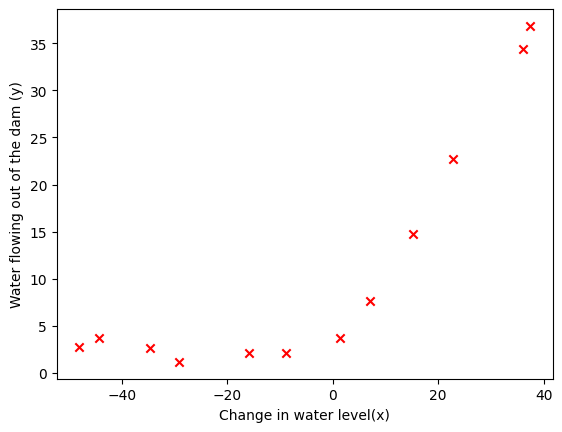

In [ ]:
import matplotlib.pylab as plt


fig , ax = plt.subplots()

ax.scatter(X[:,0],y, color='red', marker='x')

ax.set_xlabel("Change in water level(x)")
ax.set_ylabel("Water flowing out of the dam (y)")

plt.show()

## Adding an Intercept Term

Before fitting linear regression, an intercept column is added to the input matrix. This allows the model to learn a bias term in addition to the feature coefficient.

In [ ]:
import numpy as np

# This function takes a matrix as argument and returns a new matrix with an additional first column (of ones)
def add_all_ones_column(X):
    n, d = X.shape # dimension of the matrix X (n lines, d columns)
    XX = np.ones((n, d+1)) # new matrix of all ones with one additional column
    XX[:, 1:] = X # set X starting from column 1 (keep only column 0 unchanged)
    return XX

# The following line creates a new data matrix X_new with an additional first column (of ones)
X_new = add_all_ones_column(X) # for the training set
Xval_new = add_all_ones_column(Xval) # for the validation set


print("A subset of X_new:\n",X_new[:10])


A subset of X_new:
 [[  1.         -15.93675813]
 [  1.         -29.15297922]
 [  1.          36.18954863]
 [  1.          37.49218733]
 [  1.         -48.05882945]
 [  1.          -8.94145794]
 [  1.          15.30779289]
 [  1.         -34.70626581]
 [  1.           1.38915437]
 [  1.         -44.38375985]]


## Regularized Linear Regression Cost Function

This section implements the regularized linear regression objective. The regularization term penalizes large parameter values and helps reduce overfitting when the model becomes more complex.

In [ ]:
""" 
the definition of the regularized linear regression cost function. 
vectorizing the code without loops. The last argument lmd corresponds to the regularization term lambda.
"""
def E(theta, X, y, lmd):
    n = len(y)
    predictions = X @ theta
    
    errors = predictions - y
    
    cost = (1/(2*n))*(np.sum(errors**2) + (lmd*(np.sum(theta[1:] ** 2))))
    return cost


theta = np.ones(X_new.shape[1])
lambda_ = 1
cost_ = E(theta, X_new,y,lambda_)
print( f"The cost value is :{cost_:.3f}" )

The cost value is :303.993


## Gradient Computation

The gradient function computes the derivative of the regularized cost with respect to each model parameter. This is required for numerical optimization of the regression parameters.

In [ ]:

def gradE(theta, X, y, lmd):
    n = len(y)
    predictions = X @ theta
    errors = predictions - y
    grad = (1/n) * (X.T @ errors)
    reg = (lmd / n)* theta
    reg[0] = 0

    grad += reg
    return grad
    
""" 
Call the gradient function with theta initialized to an array of ones, and 
lambda = 1.
"""
theta = np.array([1,1])
lmd_ = 1
grad_val = gradE(theta, X_new, y, lmd_)
print(f"The gradient value is:{np.round(grad_val, 3)}" )

The gradient value is:[-15.303 598.251]


## Fitting a Linear Regression Baseline

A baseline linear regression model is fitted using numerical optimization. This provides an initial comparison point before exploring polynomial features and regularization.

In [ ]:
import scipy.optimize as op

theta = np.array([0, 0])  # Some initial parameters vector
lmd = 0 # We set lambda to zero this time.
print("Initial cost: ", E(theta, X_new, y, lmd))


""" 
Use op.minimize(..) to minimize the cost function E. 
printing the optimal parameter vector theta and the final cost.
"""
res = op.minimize(E,theta,args=(X_new,y,lmd),jac=gradE, method='TNC')
# Then, the optimal parameters can be accessed with: theta = res.x
theta_opt = res.x
final_cost = res.fun
print("Optimal theta is:",theta_opt)
print("Final cost is:",final_cost)

Initial cost:  140.95412088055392
Optimal theta is: [13.08790351  0.36777923]
Final cost is: 22.373906495108915


## Visualizing the Linear Regression Fit

The fitted linear model is plotted together with the training data to inspect how well a simple linear relationship explains the dataset.

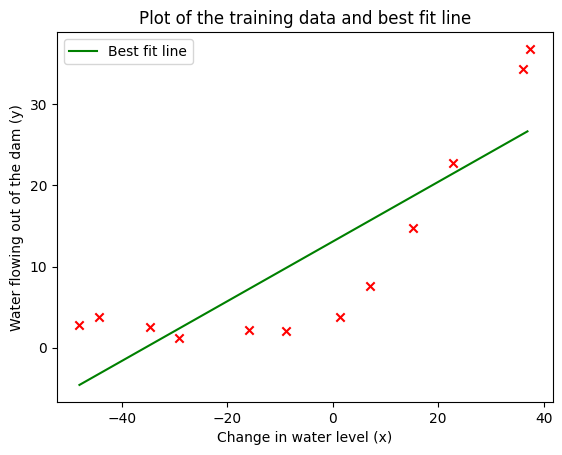

In [ ]:
# This is a function that plots the original dataset (X, y) and the best fit line:
def plot_linear_fit(X, y, theta):
    fig, ax = plt.subplots()
    
    # Plottin the training data:
    ax.scatter(X[:, 0], y, marker="x", color="red")
    ax.set_xlabel("Change in water level (x)")
    ax.set_ylabel("Water flowing out of the dam (y)")
    
    # Plotting the line:
    x_min, x_max = np.min(X[:, 0]), np.max(X[:, 0])
    plot_x = np.arange(x_min, x_max) # range of values for the x axis
    plot_y = theta[0] + theta[1] * plot_x
    ax.plot(plot_x, plot_y, color="green", label="Best fit line")
    
    ax.set_title("Plot of the training data and best fit line")
    plt.legend()
    plt.show()



plot_linear_fit(X,y,theta_opt)

## Bias-Variance and Learning Curves

Learning curves are used to compare training and validation error as the number of training examples increases. This helps diagnose underfitting, overfitting, and model generalization behavior.

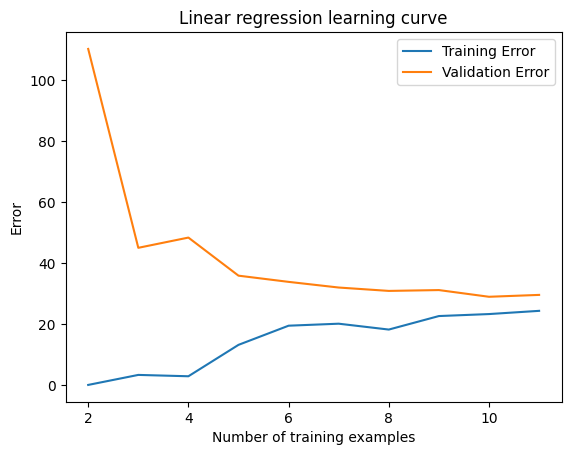

In [ ]:
# This function takes some training data, an initial theta and a regularization term 
# lmd, and returns the optimal prameters vector theta of a linear regression. It uses 
# scipy.optimize.minimize(..), the cost function E(..) and the gradient gradE(..)
def trainLinearReg(X, y, theta_init, lmd):
    res = op.minimize(E, theta_init, (X, y, lmd), 'TNC', gradE)
    return res.x # the best/final parameters vector theta


""" 
Inside a loop which iterates over the range of n (number of training examples), find the optimal theta by 
calling trainLinearReg(..) using the first i examples (X_new[:i], y[:i]), then compute the corresponding 
training error err_train (using X_new[:i], y[:i]) and the validation error err_val (using Xval_new, yval) ...
"""
errs_train, errs_val = [], [] # Lists to save the training and validation errors
for i in range(2, len(y)): # Start from 2 examples at least
    
    # finding the optimal theta parameters using the i first training examples
    X_train = X_new[:i]
    y_train = y[:i]
    
    # computing the training error using the optimal theta and the i first training examples
    theta_opt = trainLinearReg(X_train,y_train,np.ones(X_train.shape[1]), 0)
    err_train = E(theta_opt, X_train, y_train, 0)
    # computing the validation error using the optimal theta and the validation dataset
    err_val = E(theta_opt,Xval_new,yval,0)
    errs_train.append(err_train)
    errs_val.append(err_val)


#Completing the code below to plot the learning curve

fig, ax = plt.subplots()

# ploting the "number of training examples" vs the training errors
ax.plot(range(2, len(y)), errs_train, label="Training Error")

# ploting the "number of training examples" vs the validation errors
ax.plot(range(2, len(y)), errs_val, label="Validation Error")

ax.set_xlabel("Number of training examples")
ax.set_ylabel("Error")
ax.set_title("Linear regression learning curve")
ax.legend()
plt.show()

## Polynomial Feature Expansion

Polynomial features are generated to allow the model to represent nonlinear relationships. This increases model flexibility, but also increases the risk of overfitting if regularization is not used appropriately.

In [ ]:
""" 
Write the definition of the function polyFeatures(X, p) which takes 
as arguement the original training set X and the degree of the polynomial p. 
The function should return a new set X_poly of p features (i.e. matrix of len(X) rows and p columns).
"""
def polyFeatures(X, p):
    X_poly = np.ones((len(X),p))
    for i in range(1,p+1):
        X_poly[:, i-1] = np.power(X,i).reshape(-1)
    return X_poly


# some exampls to check if it works correctly.

X_test1 = np.array([2,4,6,8])
p = 3

X_1 = polyFeatures(X_test1,p)
print("The polynomial features are:\n", X_1)

The polynomial features are:
 [[  2.   4.   8.]
 [  4.  16.  64.]
 [  6.  36. 216.]
 [  8.  64. 512.]]


## Polynomial Regression Experiment

Polynomial regression is trained using the expanded feature set. This experiment demonstrates how a more flexible model can fit nonlinear patterns in the data.

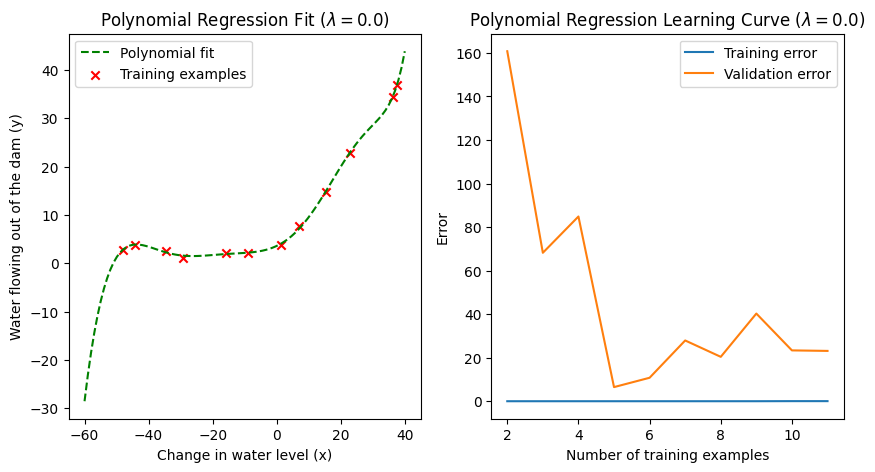

In [10]:
# The regularization parameter lmd
lmd = 0.0

# Using polyFeatures(..) with p=8 to map the original data to a higher dimension
p = 8
X_poly = polyFeatures(X, p) # on the training set
Xval_poly = polyFeatures(Xval, p) # on the validation set
Xtest_poly = polyFeatures(Xtest, p) # on the test set

# mean vector and standard deviation vector
mu = np.mean(X_poly, axis=0)
sigma = np.std(X_poly, axis=0)

# normalizing the training set and validation set using mu and sigma and adding an aditional first column of ones
X_poly_normalized = add_all_ones_column((X_poly - mu) / sigma)
Xval_poly_normalized = add_all_ones_column((Xval_poly - mu) / sigma)

# Training to find the optimal parameters vector theta
theta_init = np.zeros(p+1) # we p features, so we need p+1 parameters (as we have theta_0)
theta = trainLinearReg(X_poly_normalized, y, theta_init, lmd)

# Plotting the dataset and the polynomial regression curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_xlabel("Change in water level (x)")
ax1.set_ylabel("Water flowing out of the dam (y)")
ax1.set_title(r"Polynomial Regression Fit ($\lambda = {}$)".format(lmd))

ax2.set_xlabel("Number of training examples")
ax2.set_ylabel("Error")
ax2.set_title(r"Polynomial Regression Learning Curve ($\lambda = {}$)".format(lmd))

x_plot = np.linspace(-60, 40, 100)
x_plot_poly = polyFeatures(x_plot.reshape(len(x_plot), 1), p)
x_plot_poly_normalized = add_all_ones_column((x_plot_poly - mu) / sigma)
y_plot = x_plot_poly_normalized @ theta
ax1.plot(x_plot, y_plot, linestyle="--", color="green", label="Polynomial fit")
ax1.scatter(X[:, 0], y, marker="x", color="red", label = "Training examples")

# Plotting the learning curves using the training and validation sets
errs_train, errs_val = [], []
for i in range(2, len(y)):
    theta = trainLinearReg(X_poly_normalized[:i], y[:i], theta_init, lmd)
    errs_train.append( E(theta, X_poly_normalized[:i], y[:i], 0) )
    errs_val.append( E(theta, Xval_poly_normalized, yval, 0) )
    
ax2.plot(range(2, len(y)), errs_train, label="Training error")
ax2.plot(range(2, len(y)), errs_val, label="Validation error")

ax1.legend()
ax2.legend()
plt.show()

## Regularization Parameter Analysis

Different values of the regularization parameter are evaluated to understand how regularization affects model complexity, training error, and validation error.

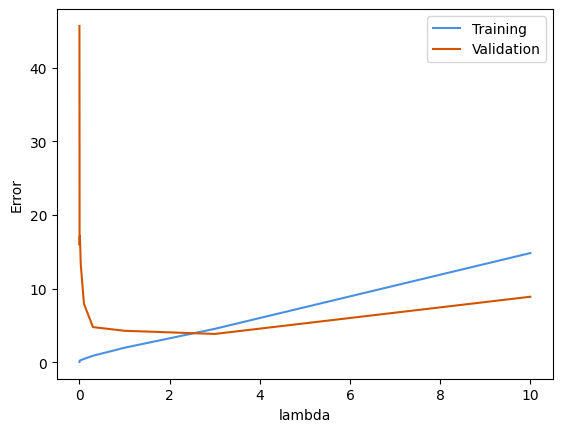

In [ ]:
lmd_range = [0, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]
errs_train, errs_val = [], []

""" 
For each value of lmd we call trainLinearReg(..) to train a model using the training set 
X_poly_normalized, y, then compute the training error (on the training set: X_poly_normalized, y) 
and the validation error (on the validation set: Xval_poly_normalized, yval).
"""
for lmd in lmd_range:
    theta = trainLinearReg(X_poly_normalized, y, np.zeros(p+1),lmd)

    err_train = E(theta, X_poly_normalized, y,0)
    errs_train.append(err_train)

    err_val = E(theta, Xval_poly_normalized, yval, 0)
    errs_val.append(err_val)


""" 
Plot a curve that shows the validation error and training error with respect to lambda
"""
fig, ax = plt.subplots()

# Plot of the training errors vs lambda values
ax.plot(lmd_range,errs_train,color = '#4A90E2',label = 'Training')
# Plot of the validation errors vs lambda values
ax.plot(lmd_range,errs_val,color = '#D35400',label ='Validation')

ax.set_xlabel("lambda")
ax.set_ylabel("Error")
ax.legend()
plt.show()


## Test Set Evaluation

After selecting a model configuration, test error is computed to estimate performance on unseen data.

In [ ]:
""" 
Finding the best parameters vector theta by training the polynomial regression 
model using lambda = 3 and then computing the error on the test set.
"""
final_lambda = 3
theta_opt = trainLinearReg(X_poly_normalized,y,np.zeros(p+1),final_lambda)

Xtest_poly_normalized = add_all_ones_column((Xtest_poly - mu)/sigma)
err_test = E(theta_opt,Xtest_poly_normalized, ytest, 0)

print("err_test =", err_test)

err_test = 3.5720457566720105


## Additional Experiment: 10-Fold Cross-Validation

This additional experiment applies repeated cross-validation to estimate model behavior across different training and validation splits. It provides a more robust comparison of regularization settings.

In [ ]:
""" 
Ploting the learning curves based on randomly selected examples as described above.
"""
from sklearn.model_selection import KFold

# Combine X with Xval
Xall = np.append(X_poly_normalized, Xval_poly_normalized, axis = 0)
# Combine y with yval
yall = np.append(y, yval, axis = 0)
# Perform a 10-fold-cross-validation to find the best value for the hyperparameter lambda
kf = KFold(n_splits=10, shuffle=True, random_state=42)

lambdas = [0,0.003,0.01,0.03,0.1,0.3,1,3,10]

mean_val_errors = []
for lmd in lmd_range:
    val_errors = []
    
    for train_index, val_index in kf.split(Xall):
        X_train_fold, X_val_fold = Xall[train_index], Xall[val_index]
        y_train_fold, y_val_fold = yall[train_index], yall[val_index]

        theta = trainLinearReg(X_train_fold, y_train_fold, np.zeros(p+1), lmd)
        val_error = E(theta, X_val_fold, y_val_fold, 0)
        val_errors.append(val_error)

    mean_val_errors.append(np.mean(val_errors))

best_lambda = lambdas[np.argmin(mean_val_errors)]
print("The best lambda is:", best_lambda)

final_theta = trainLinearReg(Xall, yall, np.zeros(p+1), best_lambda)

Xtest_poly_normalized = add_all_ones_column((Xtest_poly - mu) / sigma)
test_error = E(theta_final, Xtest_poly_normalized, ytest, 0)

print(f"The final test error with the best lambda is:{test_error:.3f}")

The best lambda is: 0.3
The final test error with the best lambda is:5.119


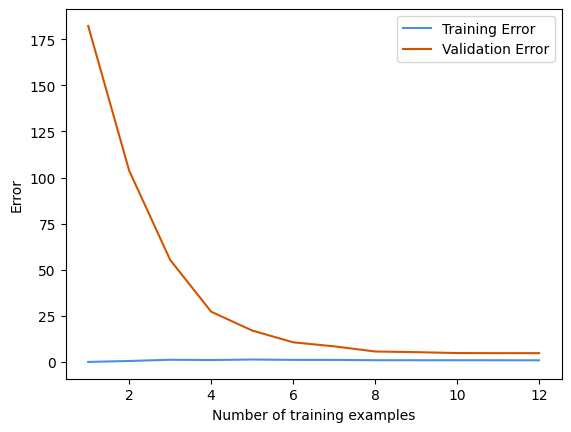

In [28]:
m_max = X_poly_normalized.shape[0] 
n_repeats = 50

errors_train = np.zeros(m_max)
errors_val = np.zeros(m_max)

for m in range(1, m_max + 1):
    train_errs = []
    val_errs = []
    
    for n in range(n_repeats):
        rand_indices = np.random.choice(m_max, m, replace=False)
        X_train_subset = X_poly_normalized[rand_indices]
        y_train_subset = y[rand_indices]

        theta = trainLinearReg(X_train_subset, y_train_subset, np.zeros(X_train_subset.shape[1]), best_lambda)

        train_errs.append(E(theta, X_train_subset, y_train_subset, 0))
        val_errs.append(E(theta, Xval_poly_normalized, yval, 0))

    errors_train[m-1] = np.mean(train_errs)
    errors_val[m-1] = np.mean(val_errs)
                             
fig, ax = plt.subplots()

ax.plot(range(1,m_max + 1), errors_train, label="Training Error",color = '#4A90E2')
ax.plot(range(1,m_max + 1), errors_val, label="Validation Error",color = '#D35400')

ax.set_xlabel("Number of training examples")
ax.set_ylabel("Error")
ax.legend()
plt.show()


## Experiment Summary

This experiment demonstrates how regularization and model complexity affect regression performance. A simple linear model provides a useful baseline, while polynomial features allow the model to capture nonlinear relationships. Validation and test errors are used to compare model behavior and select a more appropriate regularization setting.

From a portfolio perspective, this notebook shows implementation-level understanding of regression cost functions, gradients, learning curves, polynomial feature engineering, and bias-variance analysis.